Visualisation of misclassification patterns

In [1]:
%load_ext autoreload
%autoreload 2

# Libraries

In [2]:
import os
import sys
from pathlib import Path
sys.path.append(
    str(Path('..', 'utils_functionality', 'split_utils'))
)
sys.path.append(
    str(Path('..', 'utils_functionality', 'models'))
)

from modelling4_utils import (
    MLPipeline, StatsModelsEstimator)
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
from IPython.display import clear_output
from sklearn.metrics import confusion_matrix

# Misclassification patterns

## Datasets load

In [3]:
path_data = Path('../data')
df_main = pd.read_excel(path_data / 'df_main.xlsx')
df_dimless = pd.read_excel(path_data / 'df_dimless.xlsx')
df_split_nofr = pd.read_excel(path_data / 'df_ml_split_no_fragmentation.xlsx')
df_real_targets = df_main[['splashing', 'no_fragmentation', 'breaking_up', 'rebound']].copy()

## Splashing

In [4]:
target = 'splashing'

In [5]:
pipeline_cb_spl = joblib.load('../results/models_modelling4/CatBoostClassifier_splashing_smote_default')
cb_model = pipeline_cb_spl.named_steps['estimator']
ml_pipe = MLPipeline(
    target=target,
    estimator=cb_model,
    features_to_drop = (),
    model_postfix='test',)
clear_output()
X_test_spl = ml_pipe.test[cb_model.feature_names_]
y_test_spl = ml_pipe.test[target]
y_pred_cb_spl = pipeline_cb_spl.predict(X_test_spl)

In [6]:
df_targets_test_spl = df_real_targets.loc[y_test_spl.index]
df_targets_test_spl['preds_cb'] = y_pred_cb_spl

In [7]:
misclass_spl_cb = df_targets_test_spl.loc[
    df_targets_test_spl['splashing']!=df_targets_test_spl['preds_cb']]
misclass_spl_cb #[misclass_spl_cb['splashing']==0].iloc[:, 1:-1]

,splashing,no_fragmentation,breaking_up,rebound,preds_cb
328,0,0,1,0,1
300,0,0,1,0,1
243,1,0,0,0,0
38,1,0,0,0,0
144,0,1,0,0,1
282,0,0,0,2,1
58,1,0,0,0,0
327,0,0,1,0,1


In [35]:
columns_onehot = ['splashing', 'rebound', 'no_fragmentation', 'breaking_up']
misclass_spl_cb_onehot = pd.get_dummies(misclass_spl_cb.iloc[:, :-1], 
                                        columns=columns_onehot)
dfs_spl_cb_miscl = [] 
for target_value in [f'{target}_0', f'{target}_1']:
    df_current = pd.DataFrame(misclass_spl_cb_onehot[
        misclass_spl_cb_onehot[target_value]==1].sum(axis=0)).T
    dfs_spl_cb_miscl.append(df_current)
df_plot_cb_spl = pd.concat(dfs_spl_cb_miscl).iloc[:, 2:]
df_plot_cb_spl

,rebound_0,rebound_2,no_fragmentation_0,no_fragmentation_1,breaking_up_0,breaking_up_1
0,4,1,4,1,2,3
0,3,0,3,0,3,0


In [36]:
df_plot_cb_spl.index = ['No splashing', 'Splashing']
df_plot_cb_spl.rename(columns={'rebound_0': 'No rebound', 'rebound_2': 'Total rebound', 
                        'no_fragmentation_0': 'Fragmentation', 'no_fragmentation_1': 'No fragmentation',
                        'breaking_up_0': 'No breaking up', 'breaking_up_1': 'Breaking up'}, inplace=True)
df_plot_cb_spl

,No rebound,Total rebound,Fragmentation,No fragmentation,No breaking up,Breaking up
No splashing,4,1,4,1,2,3
Splashing,3,0,3,0,3,0


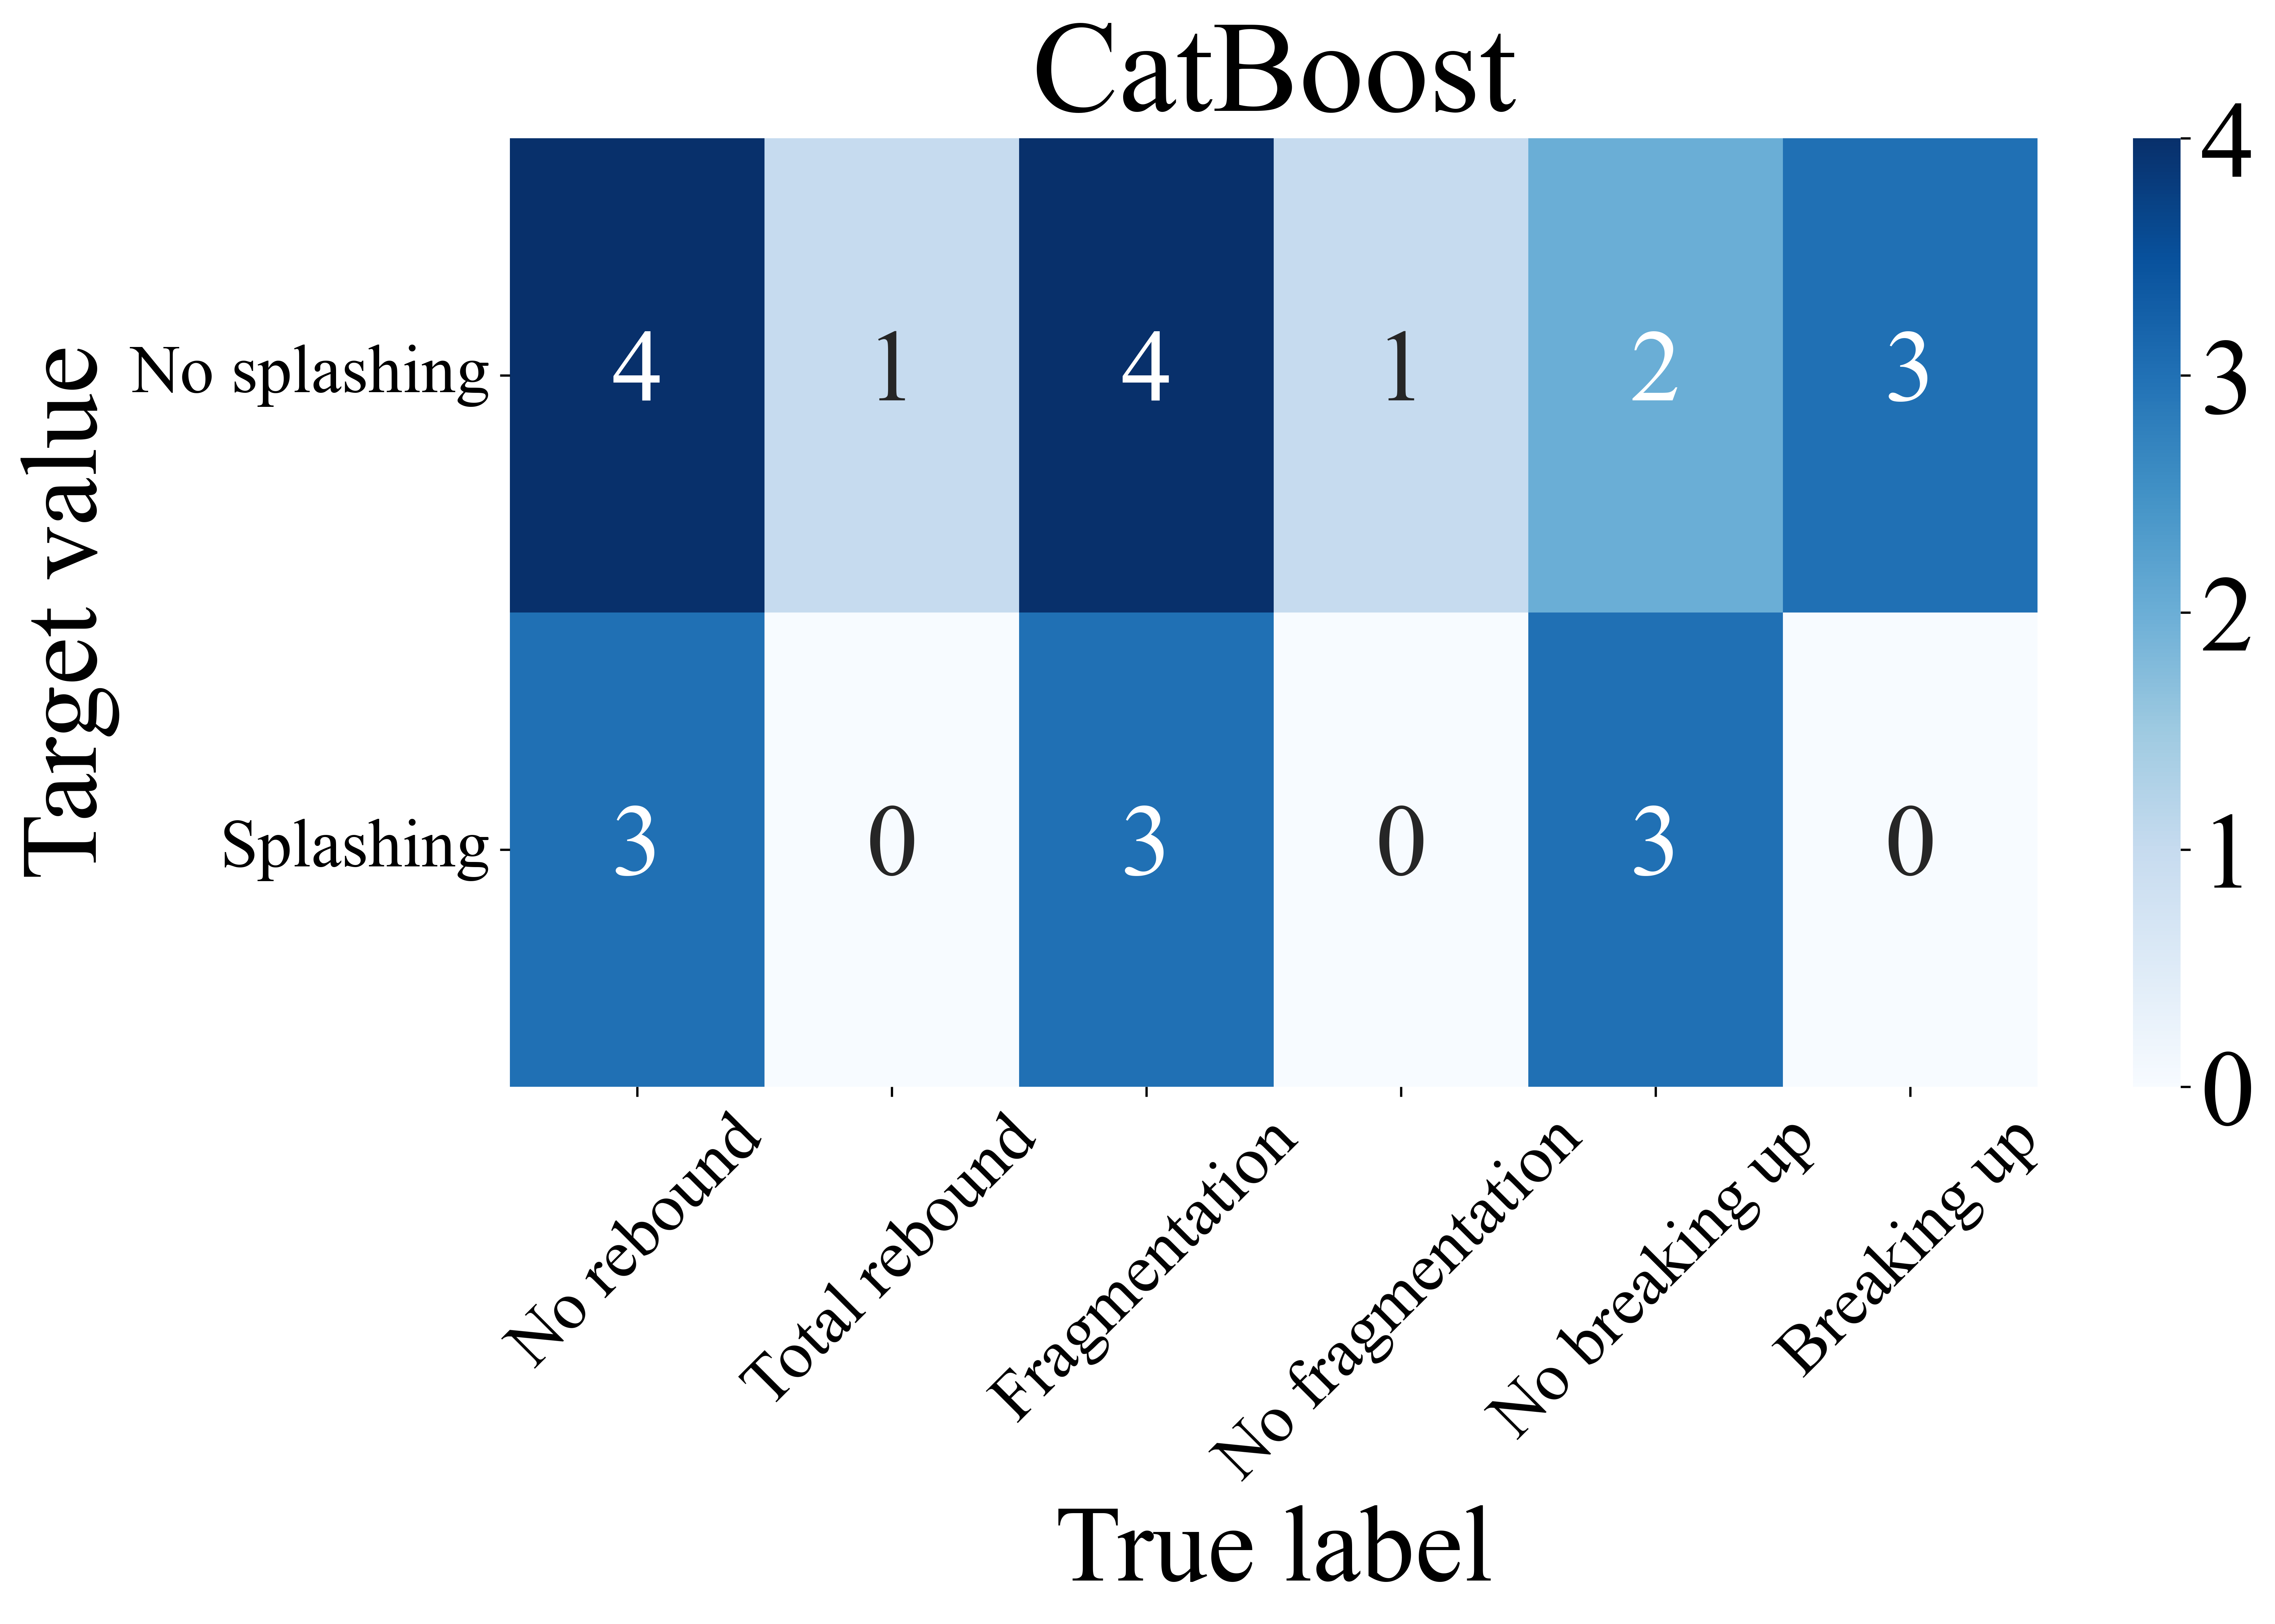

In [37]:
plt.figure(figsize=(12, 6), dpi=600)
plt.rcParams.update({'font.size': 38, 'font.family': 'Times New Roman'})
ax = sns.heatmap(df_plot_cb_spl, annot=True, cmap='Blues', annot_kws={'size': 36})
plt.ylabel('Target value')
plt.xlabel('True label')
ax.tick_params(axis='x', labelsize=24, rotation=45)
ax.tick_params(axis='y', labelsize=24)
plt.title('CatBoost')
plt.show()

In [38]:
pipeline_logit_spl = joblib.load('../results/models_modelling4/Logit_splashing_smote_default')
logit_model = pipeline_logit_spl.named_steps['estimator']
ml_pipe = MLPipeline(
    target=target,
    estimator=logit_model,
    features_to_drop = (),
    model_postfix='test',)
clear_output()
X_test_spl = ml_pipe.test[cb_model.feature_names_]
y_test_spl = ml_pipe.test[target]
y_pred_logit_spl = pipeline_logit_spl.predict(X_test_spl)

In [39]:
df_targets_test_spl = df_real_targets.loc[y_test_spl.index]
df_targets_test_spl['preds_logit'] = y_pred_logit_spl

In [40]:
misclass_spl_logit = df_targets_test_spl.loc[
    df_targets_test_spl['splashing']!=df_targets_test_spl['preds_logit']]
misclass_spl_logit

,splashing,no_fragmentation,breaking_up,rebound,preds_logit
328,0,0,1,0,1.0
93,1,0,0,0,0.0
300,0,0,1,0,1.0
243,1,0,0,0,0.0
80,1,0,1,1,0.0
38,1,0,0,0,0.0
144,0,1,0,0,1.0
337,0,0,1,0,1.0
86,1,0,0,0,0.0
282,0,0,0,2,1.0


In [41]:
columns_onehot = ['splashing', 'rebound', 'no_fragmentation', 'breaking_up']
misclass_spl_logit_onehot = pd.get_dummies(misclass_spl_logit.iloc[:, :-1], 
                                        columns=columns_onehot)
dfs_spl_logit_miscl = [] 
for target_value in [f'{target}_0', f'{target}_1']:
    df_current = pd.DataFrame(misclass_spl_logit_onehot[
        misclass_spl_logit_onehot[target_value]==1].sum(axis=0)).T
    dfs_spl_logit_miscl.append(df_current)
df_plot_logit_spl = pd.concat(dfs_spl_logit_miscl).iloc[:, 2:]
df_plot_logit_spl

,rebound_0,rebound_1,rebound_2,no_fragmentation_0,no_fragmentation_1,breaking_up_0,breaking_up_1
0,6,0,3,8,1,4,5
0,5,1,1,7,0,5,2


In [45]:
df_plot_logit_spl.index = ['No splashing', 'Splashing']
df_plot_logit_spl.rename(columns={'rebound_0': 'No rebound', 'rebound_1': 'Partial rebound', 'rebound_2': 'Total rebound', 
                        'no_fragmentation_0': 'Fragmentation', 'no_fragmentation_1': 'No fragmentation',
                        'breaking_up_0': 'No breaking up', 'breaking_up_1': 'Breaking up'}, inplace=True)
df_plot_logit_spl

,No rebound,Partial rebound,Total rebound,Fragmentation,No fragmentation,No breaking up,Breaking up
No splashing,6,0,3,8,1,4,5
Splashing,5,1,1,7,0,5,2


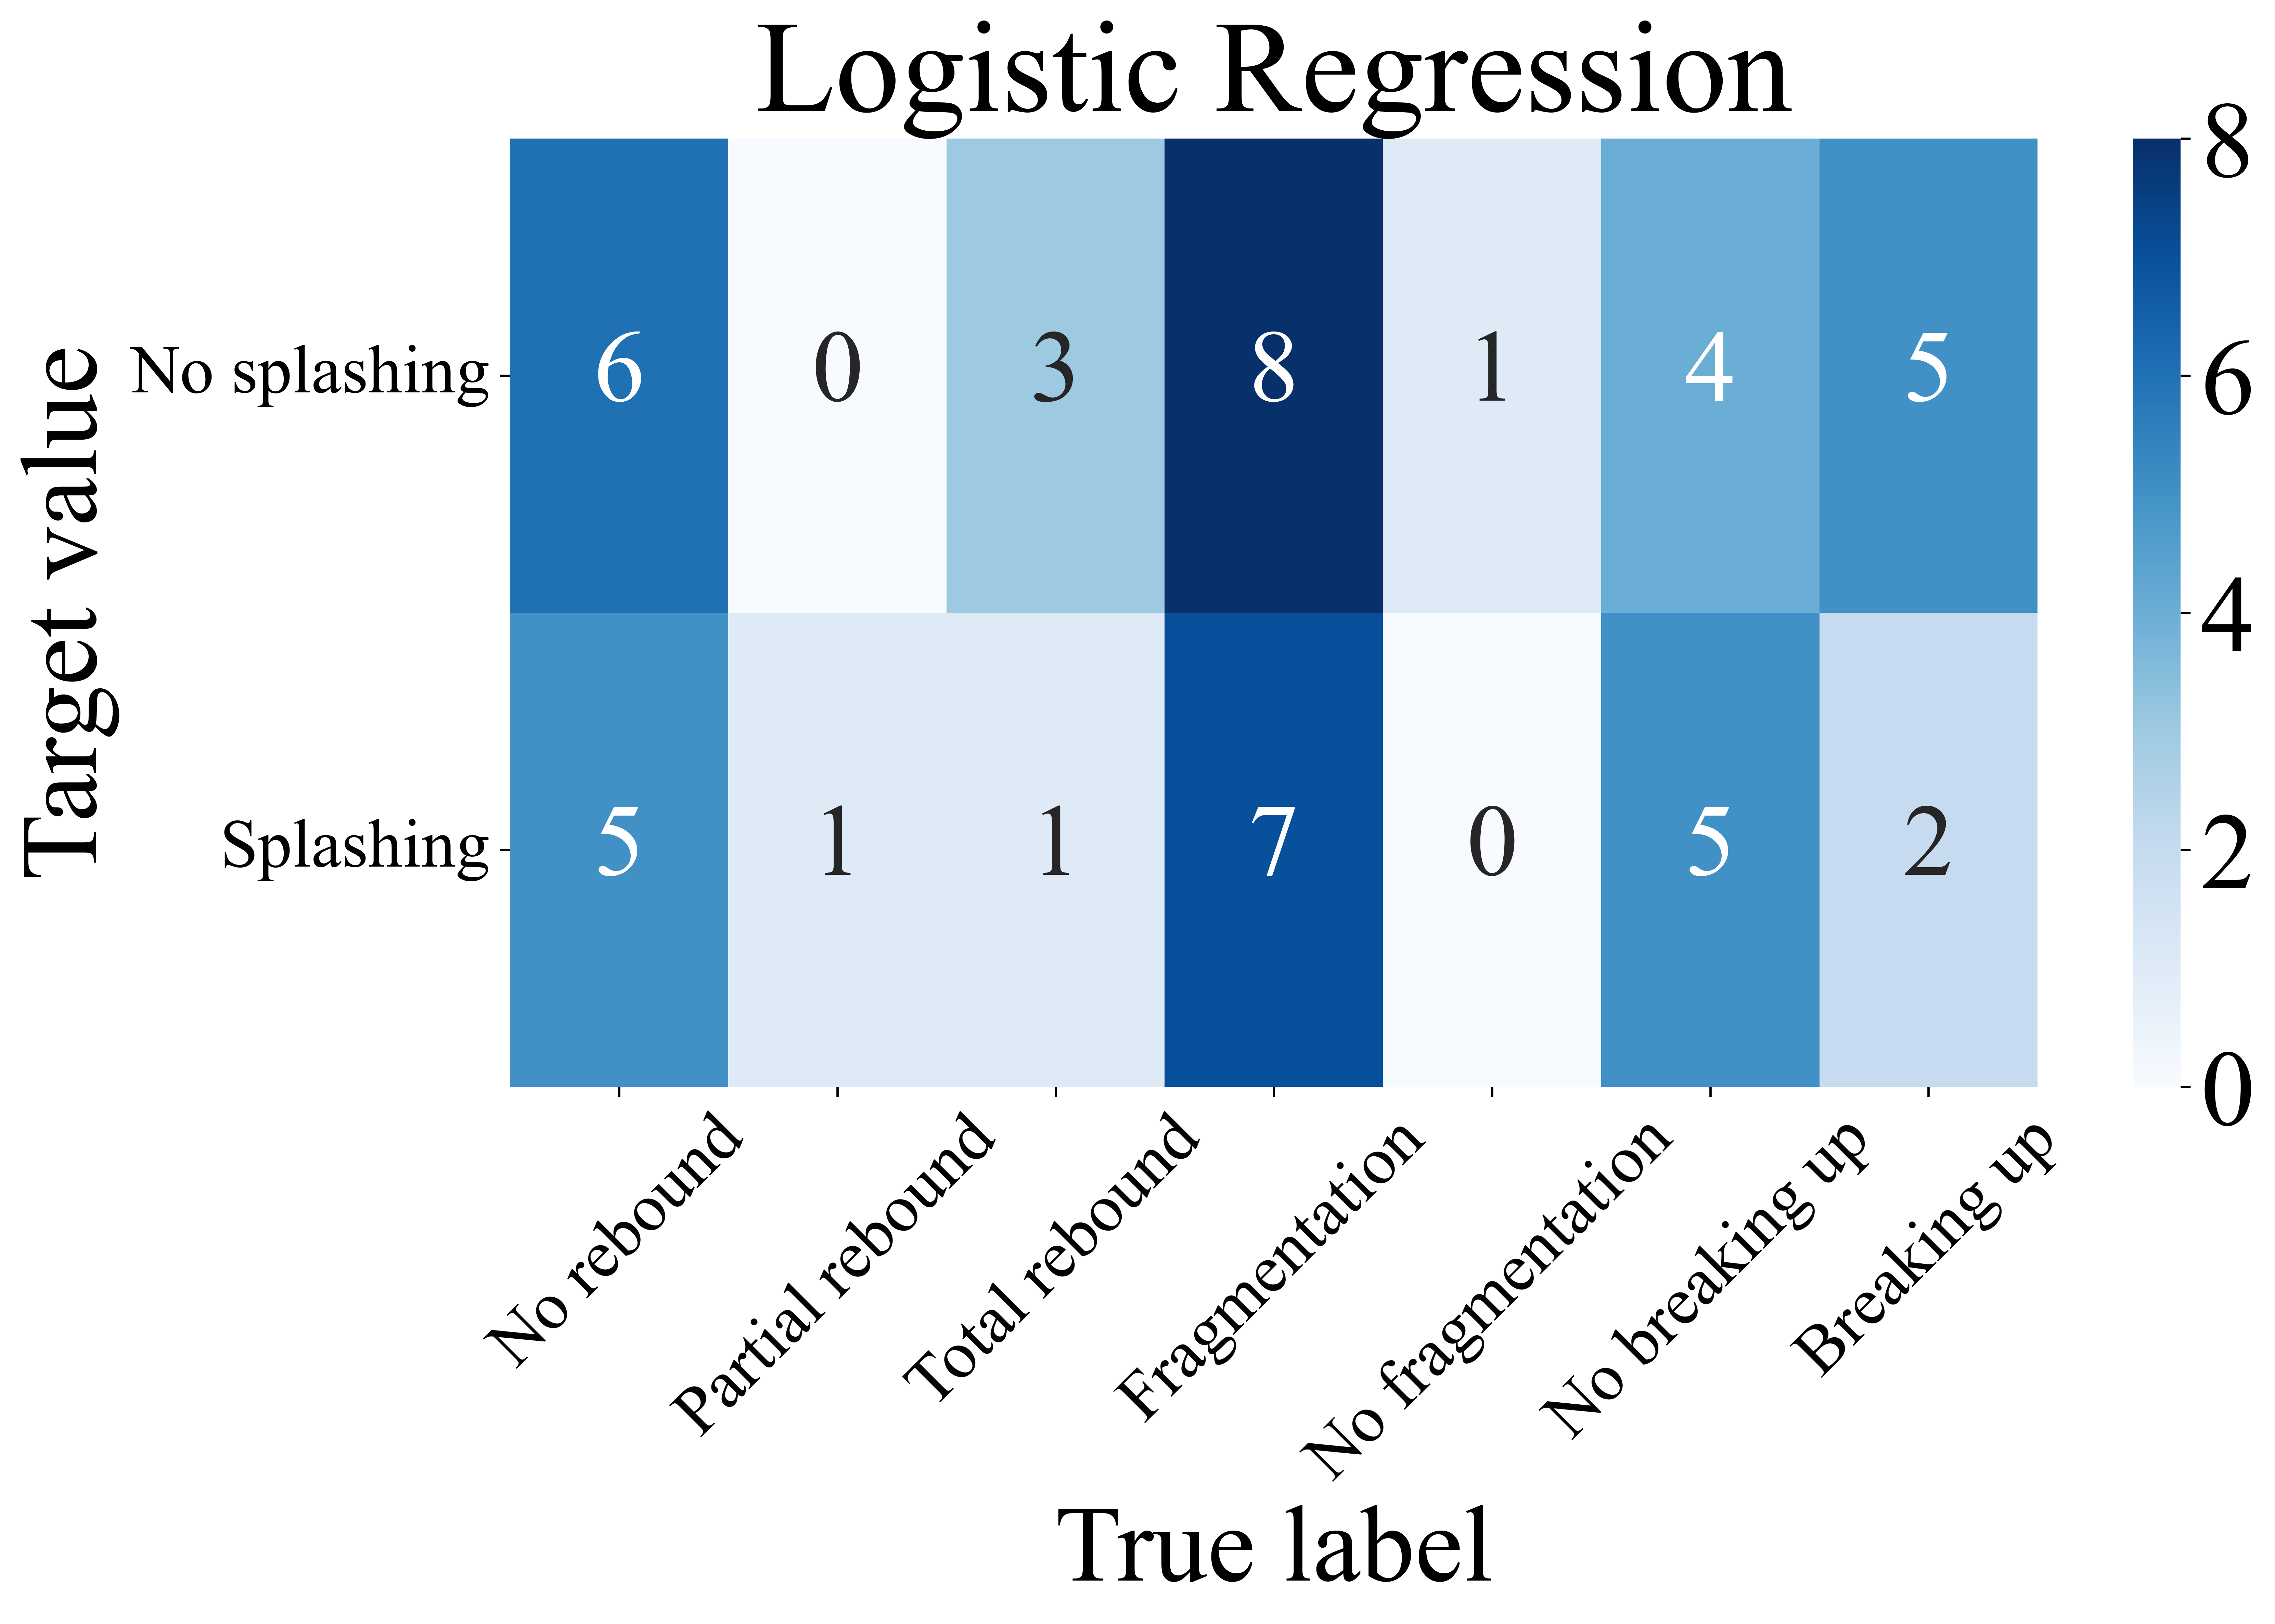

In [46]:
plt.figure(figsize=(12, 6), dpi=600)
plt.rcParams.update({'font.size': 38, 'font.family': 'Times New Roman'})
ax = sns.heatmap(df_plot_logit_spl, annot=True, cmap='Blues', annot_kws={'size': 36})
plt.ylabel('Target value')
plt.xlabel('True label')
ax.tick_params(axis='x', labelsize=24, rotation=45)
ax.tick_params(axis='y', labelsize=24)
plt.title('Logistic Regression')
plt.show()

<Figure size 19200x14400 with 0 Axes>

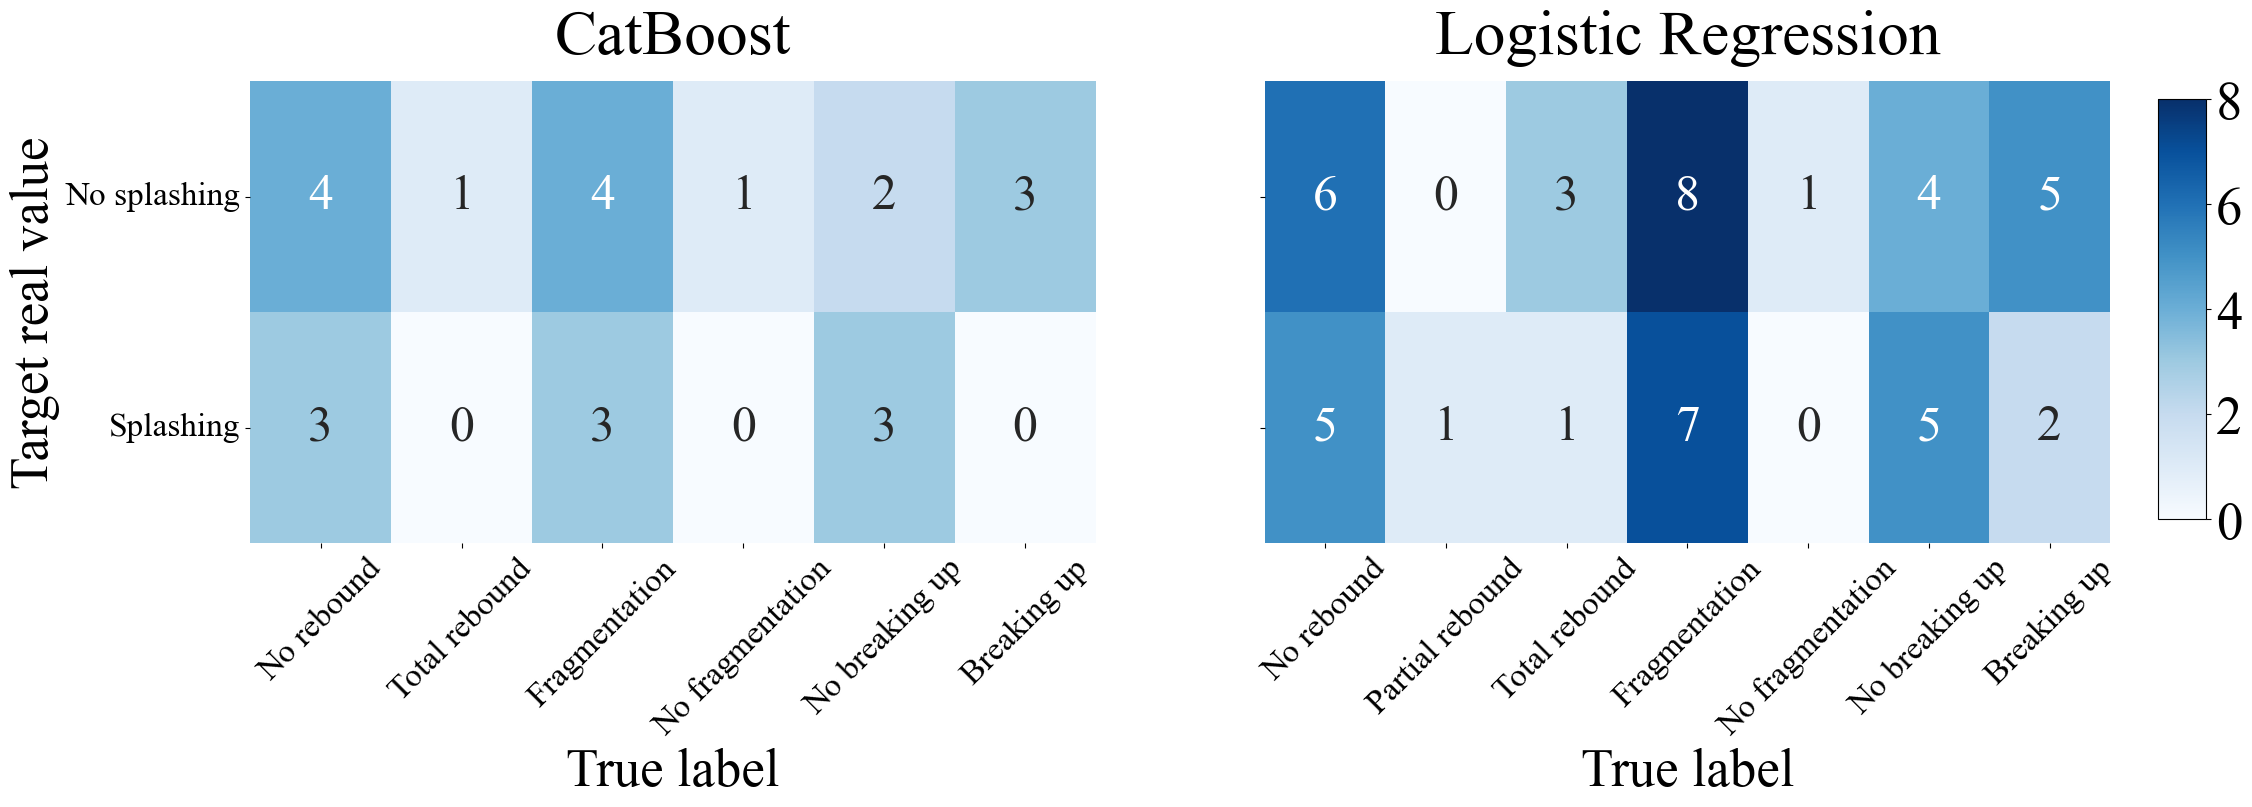

In [59]:
plt.figure(figsize=(24, 18), dpi=800)
plt.rcParams.update({'font.size': 38, 'font.family': 'Times New Roman'})

# Create subplots with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 6), sharey=True)

# Find the global min and max for consistent color scaling
vmin = min(df_plot_cb_spl.min().min(), df_plot_logit_spl.min().min())
vmax = max(df_plot_cb_spl.max().max(), df_plot_logit_spl.max().max())

# First heatmap (CatBoost)
sns.heatmap(df_plot_cb_spl, annot=True, cmap='Blues', annot_kws={'size': 36}, 
            cbar=False, ax=ax1, vmin=vmin, vmax=vmax)
ax1.set_ylabel('Target real value')
ax1.set_xlabel('True label')
ax1.tick_params(axis='x', labelsize=24, rotation=45)
ax1.tick_params(axis='y', labelsize=24)
ax1.set_title('CatBoost', pad=20)

# Second heatmap (Logistic Regression)
sns.heatmap(df_plot_logit_spl, annot=True, cmap='Blues', annot_kws={'size': 36}, 
            cbar=False, ax=ax2, vmin=vmin, vmax=vmax)
ax2.set_xlabel('True label')
ax2.tick_params(axis='x', labelsize=24, rotation=45)
ax2.tick_params(axis='y', labelsize=24)
ax2.set_title('Logistic Regression', pad=20)

# Add a common colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, cax=cbar_ax)

# Set the number of ticks (e.g., 10 evenly spaced values)
cbar.locator = plt.MaxNLocator(nbins=4)  # Adjust `nbins` for more/less ticks
cbar.update_ticks()

# plt.tight_layout(rect=[0, 0, 0.9, 1])  
plt.show()